In [1]:
# title import pkg
import warnings

warnings.filterwarnings("ignore")

import sys
import os


import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

#plt.style.use("ggplot")
sns.set_theme(style="ticks")
sns.set_context("paper")
sns.color_palette("husl", 8)
#plt.style.use('grayscale')

import re
from tqdm import tqdm
from IPython.display import clear_output

from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.linear_model import (
    LogisticRegressionCV,
    LassoCV,
    Lasso,
    LogisticRegression,
)


sys.path.append(os.path.abspath("../"))
from dmldid.model_rcs import DMLDiD_RCS

from dmldid.simdata_genrater import generate_simdata_ro, convert_rcs

# Verification with simulation data
## simulation data
-  repeated cross-section data
- true ATT := 3
- dim(X) := 100
- N = 600

In [2]:
df_rcs = convert_rcs(
    generate_simdata_ro(true_att=3, _n=500, _dim=1000, base_seed=1, xd_unobserved=False)
)

df_rcs.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x993,x994,x995,x996,x997,x998,x999,D,Y,T
0,1.624345,-0.611756,-0.528172,-1.072969,0.865408,-2.301539,1.744812,-0.761207,0.319039,-0.249370,...,0.718291,1.291189,-0.116444,-2.277298,-0.069625,0.353870,-0.186955,0,-3.481885,0
1,-0.153236,-2.432509,0.507984,-0.324032,-1.511077,-0.871422,-0.864830,0.608749,0.561638,1.514750,...,-1.407064,-0.447473,0.188583,0.560918,-0.921659,0.647375,1.386826,0,-25.879270,1
2,0.489517,0.238796,-0.448112,-0.610795,-2.029945,0.607947,-0.354109,0.152581,0.501275,-0.786403,...,0.233113,-1.802722,-0.771890,-0.622657,-0.150660,-1.400023,-1.301066,0,-5.540999,0
3,-0.077107,0.207825,0.986196,1.432756,0.528258,-0.367732,0.691721,-0.798347,0.213818,1.789976,...,1.184304,-0.794843,-0.125903,-0.960346,-0.843913,0.628342,0.537214,1,-3.750312,0
4,-0.140371,0.141642,0.311969,0.769085,0.584286,1.788593,-0.024631,1.490290,-0.321077,0.560806,...,1.837916,0.584679,1.604546,0.566613,-0.775988,1.084889,2.241989,0,-4.355537,0


## naive DiD

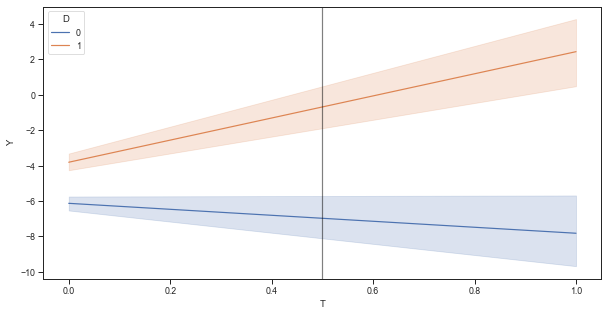

In [3]:
fig, ax = plt.subplots(1, 1, sharex="col", sharey="row", figsize=(10, 5))
sns.lineplot(x="T", y="Y", hue="D", data=df_rcs, ax=ax)
ax.axvline(x=0.5, alpha=0.5, color="black")
plt.show()

In [4]:
y_col = "Y"
d_col = "D"
t_col = "T"
X_cols = [col for col in df_rcs.columns if "x" in col]

# My solution:
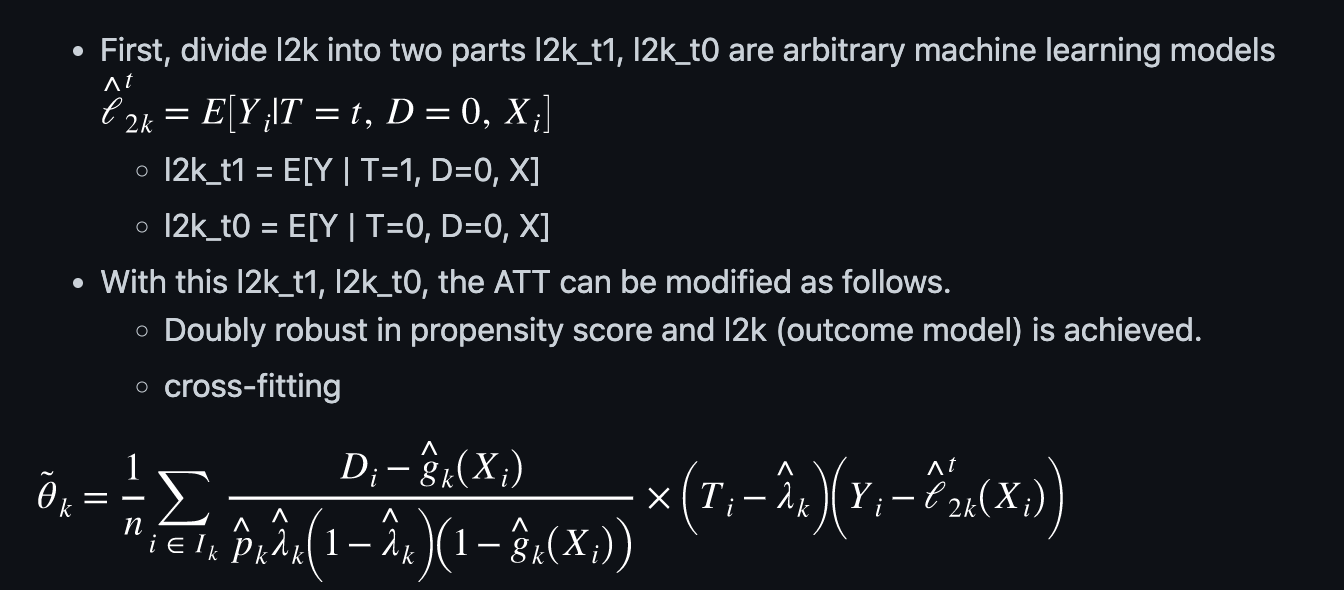

- linear_dmldid employs LogisticRegressionCV and LassoCV for l2k
- lgbm_dmldid employs LGBM for l2k

# Chang(2020)
- The following R code is from [Chang (2020)](https://github.com/NengChiehChang/Diff-in-Diff/blob/master/Table%202/DMLML.R).
- DMLML:Unchanged except for the addition of a progress bar
- fixed_DMLML: The concept of Chang(2020) is unchanged. However, an obvious implementation error was corrected.

# x->d unobserved

In [5]:
linear_dml_with_separate = []
linear_dml = []
abadie_semidid = []

Y_list = []
D_list = []
T_list = []
X_list = []

y_col = "Y"
d_col = "D"
t_col = "T"

sim_cnt = 1000
for i in range(sim_cnt):
    df = convert_rcs(
        generate_simdata_ro(_dim=100, _n=500, base_seed=i, xd_unobserved=True)
    )
    X_cols = [col for col in df.columns if "x" in col]

    linear_dmldid = DMLDiD_RCS(
        d_model=LogisticRegressionCV(
            cv=5, random_state=123, penalty="l1", solver="saga"
        ),
        l2k_model=LassoCV(cv=5, random_state=123),
    )
    linear_dmldid.fit(
        df,
        y_col,
        d_col,
        t_col,
        X_cols,
        dmldid=True,
        sim_cnt=1,
        base_random_seed=0,
        d_model_t0_only=False,
        l2k_model_separate=True,
    )
    linear_dml_with_separate.append(linear_dmldid.att())
    
    linear_dmldid = DMLDiD_RCS(
        d_model=LogisticRegressionCV(
            cv=5, random_state=123, penalty="l1", solver="saga"
        ),
        l2k_model=LassoCV(cv=5, random_state=123),
    )
    linear_dmldid.fit(
        df,
        y_col,
        d_col,
        t_col,
        X_cols,
        dmldid=True,
        sim_cnt=1,
        base_random_seed=0,
        d_model_t0_only=False,
        l2k_model_separate=False,
    )
    linear_dml.append(linear_dmldid.att())

    linear_dmldid = DMLDiD_RCS(
        d_model=LogisticRegressionCV(
            cv=5, random_state=123, penalty="l1", solver="saga"
        ),
        l2k_model=LassoCV(cv=5, random_state=123),
    )
    linear_dmldid.fit(
        df,
        y_col,
        d_col,
        t_col,
        X_cols,
        dmldid=False,
        sim_cnt=1,
        base_random_seed=0,
        d_model_t0_only=False,
    )
    abadie_semidid.append(linear_dmldid.att())

    clear_output(wait=True)
    print(f"{i} modified DMLDiD no separate: ", np.mean(linear_dml))
    print(f"{i} modified DMLDiD : ", np.mean(linear_dml_with_separate))
    print(f"{i} abadie_semidid : ", np.mean(abadie_semidid))

    Y_list.append(df[[y_col]].to_numpy())
    D_list.append(df[[d_col]].to_numpy())
    T_list.append(df[[t_col]].to_numpy())
    X_list.append(df[X_cols].astype(float).to_numpy())

999 modified DMLDiD no separate:  5.829422522490938
999 modified DMLDiD :  3.0121644726162127
999 abadie_semidid :  6.519386105380278


In [6]:
%load_ext rpy2.ipython

In [7]:
%R  -i Y_list
%R  -i D_list
%R  -i T_list
%R  -i X_list

In [8]:
%%R
library(glmnet)

DMLML=function(Y,D,p,T){
  N=length(Y)
  B=1
  set.seed(123)
  random=sample(1:1000,B)
  
  thetabar=c(0)
  
  for (l in 1:B){
    k=2
    
    samplesplit=function(k,N){
      c1=1:N
      smp_size <- floor((1/k) * length(c1))
      
      ## set the seed to make your partition reproducible
      set.seed(random[l])
      train_ind <- sample(seq_len(length(c1)), size = smp_size)
      
      k1 <- c1[train_ind]
      k2 <- c1[-train_ind]
      return(rbind(k1,k2))
    }
    K=samplesplit(k,N)
    
    thetaDML=c(0)
    
    for (q in 1:k){
      ##Trimming
      set.seed(333)
      CV=cv.glmnet(p[-K[q,],],D[-K[q,]],family="binomial",alpha=1)
      fit=glmnet(p[-K[q,],],D[-K[q,]],family="binomial",alpha=1,lambda=CV$lambda.1se)
      beta1hat=fit$beta
      beta1hat <- as.numeric(as.character(beta1hat))
      
      ghat=1/(1+exp(-p[K[q,],]%*%beta1hat))
      #ghat = predict(fit, p[K[q,],], type="response")
      
      index1=K[q,][which(ghat<0.97 & ghat>0.03)]
      
      ##Estimation
      ghat=1/(1+exp(-p[index1,]%*%beta1hat))
      #ghat = predict(fit, p[index1,], type="response")
      
      lambda=mean(T[-K[q,]])
      
      index=which(D[-K[q,]]==0)
      YY=Y[-K[q,]]
      YY=YY[index]
      TT=T[-K[q,]]
      TT=TT[index]
      XX=p[-K[q,],]
      XX=XX[index,]
      
      set.seed(333)
      CV=cv.glmnet(XX,(TT-lambda)*YY,family="gaussian",alpha=1)
      fit=glmnet(XX,(TT-lambda)*YY,family="gaussian",alpha=1,lambda=CV$lambda.1se)
      
      beta2hat=fit$beta
      beta2hat <- as.numeric(as.character(beta2hat))
      
      ellhat2=p[index1,]%*%beta2hat
      #ellhat2 = predict(fit,p[index1,])
      
      
      s=((T[index1]-lambda)*Y[index1]-ellhat2)*(D[index1]-ghat)/(1-ghat)/(lambda*(1-lambda))/mean(D[index1])
      # s=s[which(s<abs(min(s)))]
      
      thetaDML[q]=mean(s)
      
    }
    thetabar[l]=mean(thetaDML)
  }
  finaltheta=mean(thetabar)
  return(thetabar)
}

fixed_DMLML=function(Y,D,p,T){
  N=length(Y)
  B=1
  set.seed(123)
  random=sample(1:1000,B)
  
  thetabar=c(0)
  for (l in 1:B){
    k=2
    samplesplit=function(k,N){
      c1=1:N
      smp_size <- floor((1/k) * length(c1))
      
      ## set the seed to make your partition reproducible
      set.seed(random[l])
      train_ind <- sample(seq_len(length(c1)), size = smp_size)
      
      k1 <- c1[train_ind]
      k2 <- c1[-train_ind]
      return(rbind(k1,k2))
    }
    K=samplesplit(k,N)
    
    thetaDML=c(0)
    
    for (q in 1:k){
      ##Trimming
      set.seed(333)
      CV=cv.glmnet(p[-K[q,],],D[-K[q,]],family="binomial",alpha=1)
      fit=glmnet(p[-K[q,],],D[-K[q,]],family="binomial",alpha=1,lambda=CV$lambda.1se)
      beta1hat=fit$beta
      beta1hat <- as.numeric(as.character(beta1hat))
      
      #ghat=1/(1+exp(-p[K[q,],]%*%beta1hat))
      ghat = predict(fit, p[K[q,],], type="response")
      
      index1=K[q,][which(ghat<0.97 & ghat>0.03)]
      
      ##Estimation
      #ghat=1/(1+exp(-p[index1,]%*%beta1hat))
      ghat = predict(fit, p[index1,], type="response")
      
      lambda=mean(T[-K[q,]])
      
      index=which(D[-K[q,]]==0)
      YY=Y[-K[q,]]
      YY=YY[index]
      TT=T[-K[q,]]
      TT=TT[index]
      XX=p[-K[q,],]
      XX=XX[index,]
      
      set.seed(333)
      CV=cv.glmnet(XX,(TT-lambda)*YY,family="gaussian",alpha=1)
      fit=glmnet(XX,(TT-lambda)*YY,family="gaussian",alpha=1,lambda=CV$lambda.1se)
      
      beta2hat=fit$beta
      beta2hat <- as.numeric(as.character(beta2hat))
      
      #ellhat2=p[index1,]%*%beta2hat
      ellhat2 = predict(fit,p[index1,])
      
      
      s=((T[index1]-lambda)*Y[index1]-ellhat2)*(D[index1]-ghat)/(1-ghat)/(lambda*(1-lambda))/mean(D[index1])
      # s=s[which(s
      
      thetaDML[q]=mean(s)
      
    }
    thetabar[l]=mean(thetaDML)
  }
  finaltheta=mean(thetabar)
  return(thetabar)
}

r_result_list = c()
fixed_r_result_list = c()
k = length(Y_list)

pb <- txtProgressBar(min = 1, max = k, style = 3)
for (i in 1:k){
    setTxtProgressBar(pb, i)
    xx = data.matrix(data.frame(X_list[i]))
    yy = data.matrix(data.frame(Y_list[i]))
    dd = data.matrix(data.frame(D_list[i]))
    tt = data.matrix(data.frame(T_list[i]))
   r_result_list[i] = DMLML(yy ,dd ,xx ,tt)
   fixed_r_result_list[i] = fixed_DMLML(yy ,dd ,xx ,tt)
}

R[write to console]:  要求されたパッケージ Matrix をロード中です 

R[write to console]: Loaded glmnet 4.1-3



  |======================================================================| 100%

In [9]:
%R -o r_result_list
%R -o fixed_r_result_list

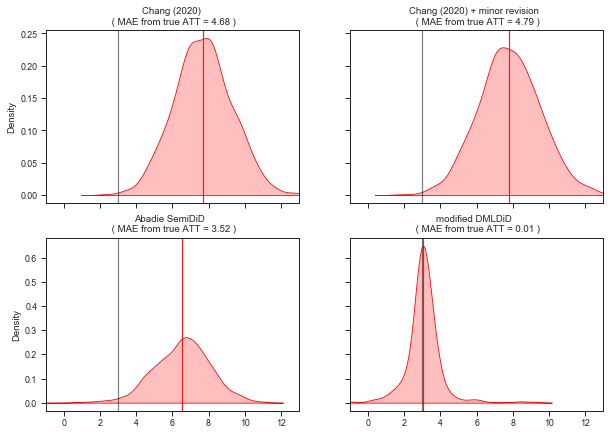

In [10]:
_label = [
    f"Chang (2020) \n ( MAE from true ATT = {np.abs(3-np.mean(r_result_list)):.2f} )",
    f"Chang (2020) + minor revision  \n ( MAE from true ATT = {np.abs(3-np.mean(fixed_r_result_list)):.2f} )",
    f"Abadie SemiDiD  \n ( MAE from true ATT = {np.abs(3-np.mean(abadie_semidid)):.2f} )",
    f"modified DMLDiD  \n ( MAE from true ATT = {np.abs(3-np.mean( linear_dml_with_separate)):.2f} )",
]
result_df = pd.DataFrame(
    {
        "original_bar": r_result_list,
        "few_fixed_bar": fixed_r_result_list,
        "abadie_semidid": abadie_semidid,
        "modified_dmldid": linear_dml_with_separate
    }
)
fig, ax = plt.subplots(2, 2, sharex="col", sharey="row", figsize=(10, 7))
ax = ax.ravel()
for i, _col in enumerate(result_df.columns):
    #ax[i].hist(result_df[_col], bins=100, alpha=0.5)
    sns.kdeplot(result_df[_col], shade=True, color="red", ax=ax[i])
    ax[i].set_xlim(-1,13)
    ax[i].set_title(_label[i])
    ax[i].axvline(x=3, alpha=0.5, color="black")
    ax[i].axvline(x=result_df[_col].mean(),  color="red", alpha=0.9)
    ax[i].set_xlabel("")

fig.savefig("../fig/simdata_result_unobserved_ps.png", dpi=300)
plt.show()

In [11]:
result_df.describe().T

,count,mean,std,min,25%,50%,75%,max
original_bar,1000.0,7.676222,1.604377,2.173281,6.636903,7.672284,8.683324,12.859490
few_fixed_bar,1000.0,7.789933,1.719090,1.667278,6.671051,7.766854,8.947552,14.206725
abadie_semidid,1000.0,6.519386,1.562039,-1.851868,5.524923,6.591630,7.530812,10.938821
modified_dmldid,1000.0,3.012164,1.160200,-6.869845,2.711123,3.032181,3.404816,9.277590


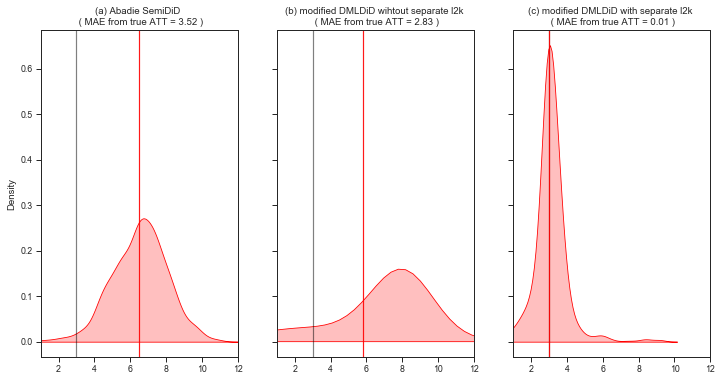

In [12]:
_label = [
    f"(a) Abadie SemiDiD \n ( MAE from true ATT = {np.abs(3-np.mean(abadie_semidid)):.2f} )",
    f"(b) modified DMLDiD wihtout separate l2k \n ( MAE from true ATT = {np.abs(3-np.mean(linear_dml)):.2f} )",
    f"(c) modified DMLDiD with separate l2k \n ( MAE from true ATT = {np.abs(3-np.mean( linear_dml_with_separate)):.2f} )",
]
result_df = pd.DataFrame(
    {
        "abadie_semidid": abadie_semidid,
        "modified_dmldid": linear_dml,
        "modified_dmldid_with_separate": linear_dml_with_separate
    }
)

fig, ax = plt.subplots(1, 3, sharex="col", sharey="row", figsize=(12, 6))
ax = ax.ravel()
for i, _col in enumerate(result_df.columns):
    sns.kdeplot(result_df[_col], shade=True, color="red", ax=ax[i])
    # ax[i].hist(result_df[_col], bins=50,color="red",alpha=0.5)
    ax[i].set_xlim(1,12)

    ax[i].set_title(_label[i])
    ax[i].axvline(x=3, alpha=0.5, color="black")
    ax[i].axvline(x=result_df[_col].mean(), color="red", alpha=0.9)
    ax[i].set_xlabel("")

fig.savefig("../fig/simdata_result_unobserved_ps_separate_or_not.png", dpi=300)
plt.show()

In [14]:
pd.DataFrame(
    {
        "original_bar": r_result_list,
        "few_fixed_bar": fixed_r_result_list,
        "abadie_semidid": abadie_semidid,
        "modified_dmldid_without_separate": linear_dml,
        "modified_dmldid_with_separate": linear_dml_with_separate
    }
).to_csv("../sim_results/dmldid_rcs_with_simdata_lasso.csv", index=False)

In [13]:
print("Done")

Done
